# Experiment 9: Newton's Method for Function Minimization

**Objective:** To implement Newton's method to find minima of multivariable functions, and to understand the role of the learning rate in controlling convergence.

---

## What is Newton's Method?

Newton's method is a powerful optimization technique that uses **both the first derivative (gradient) and the second derivative (Hessian)** of a function to find its minimum much faster than plain gradient descent.

### Intuition

Gradient Descent only asks: "Which direction is downhill?"

Newton's Method asks: "Which direction is downhill, and how curved is the surface there?"

By knowing the curvature (second derivative), Newton's method can take a smarter, better-sized step instead of a fixed step.

### Key Idea

At each step, Newton's method fits a **quadratic (parabola) approximation** to the function at the current point, then jumps directly to the minimum of that parabola.

For a single variable:
```
x_new = x_old - f'(x) / f''(x)
```

For multiple variables:
```
x_new = x_old - H_inverse * gradient
```
where H is the Hessian matrix of second derivatives.

---

## Key Terms

| Term | Meaning |
|---|---|
| Gradient | Vector of first-order partial derivatives |
| Hessian | Matrix of second-order partial derivatives |
| Learning Rate | A scaling factor (optional) to control step size |
| Convergence | When the update becomes negligibly small |
| Quadratic Approximation | A parabola fitted to the function at the current point |

---

In [5]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Example 1: Newton's Method on a Simple Quadratic Function

**Function:** f(x) = x^2

**First Derivative (Gradient):** f'(x) = 2x

**Second Derivative (Hessian):** f''(x) = 2

**Newton's Update Rule:**
```
x_new = x - f'(x) / f''(x)
      = x - 2x / 2
      = x - x
      = 0
```

For a perfect quadratic, Newton's method reaches the minimum in **exactly 1 step**, regardless of where you start. This is because a quadratic is perfectly captured by the second-order approximation.

Iteration               x         f(x)    f(x) change
----------------------------------------------------
1                0.000000     0.000000    64.00000000
2                0.000000     0.000000     0.00000000
3                0.000000     0.000000     0.00000000
4                0.000000     0.000000     0.00000000
5                0.000000     0.000000     0.00000000
6                0.000000     0.000000     0.00000000
7                0.000000     0.000000     0.00000000
8                0.000000     0.000000     0.00000000
9                0.000000     0.000000     0.00000000
10               0.000000     0.000000     0.00000000

Minimum found at x = 0.00000000,  f(x) = 0.00000000
True minimum     at x = 0.0,          f(x) = 0.0

Observation: Newton's method reaches the exact minimum in 1 step for a perfect quadratic!


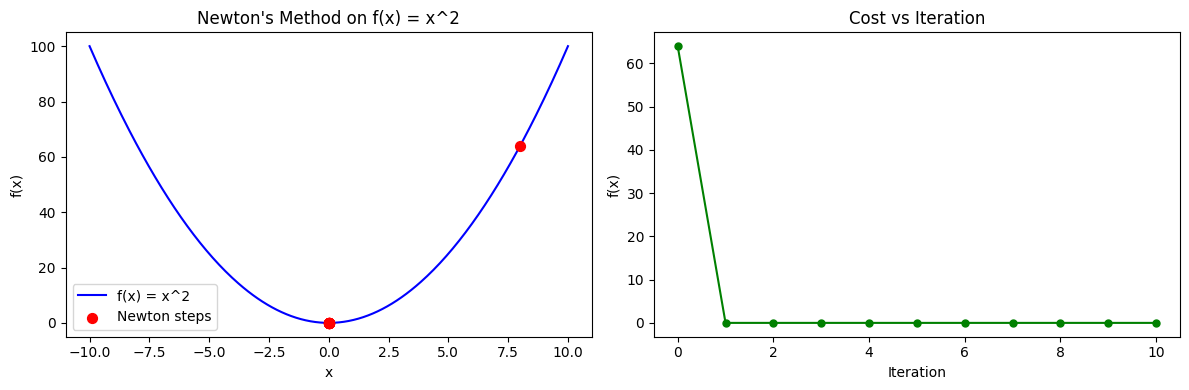

In [6]:
# Example 1: Newton's Method on f(x) = x^2

def f(x):
    return x ** 2

def grad_f(x):
    return 2 * x          # first derivative

def hessian_f(x):
    return 2              # second derivative (constant for x^2)

# Starting point
x = 8.0
iterations = 10

print(f"{'Iteration':<12} {'x':>12} {'f(x)':>12} {'f(x) change':>14}")
print("-" * 52)

history_x = [x]
history_f = [f(x)]

for i in range(iterations):
    g = grad_f(x)
    h = hessian_f(x)
    x_new = x - g / h          # Newton's update
    change = abs(f(x_new) - f(x))
    x = x_new
    history_x.append(x)
    history_f.append(f(x))
    print(f"{i+1:<12} {x:>12.6f} {f(x):>12.6f} {change:>14.8f}")

print(f"\nMinimum found at x = {x:.8f},  f(x) = {f(x):.8f}")
print(f"True minimum     at x = 0.0,          f(x) = 0.0")
print("\nObservation: Newton's method reaches the exact minimum in 1 step for a perfect quadratic!")

# Plot
x_range = np.linspace(-10, 10, 300)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_range, x_range**2, 'b-', label='f(x) = x^2')
plt.scatter(history_x, [v**2 for v in history_x], color='red', s=50, zorder=5, label='Newton steps')
plt.title("Newton's Method on f(x) = x^2")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_f, 'g-o', markersize=5)
plt.title('Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('f(x)')

plt.tight_layout()
plt.show()

---
## Example 2: Newton's Method vs Gradient Descent (Speed Comparison)

**Function:** f(x) = x^4 - 3x^3 + 2

**First Derivative:** f'(x) = 4x^3 - 9x^2

**Second Derivative:** f''(x) = 12x^2 - 18x

This example compares how many iterations each method needs to converge.
Newton's method typically needs far fewer iterations because it uses curvature information.

Newton's Method  -- Final x: 2.250000,  f(x): -6.542969
Gradient Descent -- Final x: 2.254097,  f(x): -6.542798


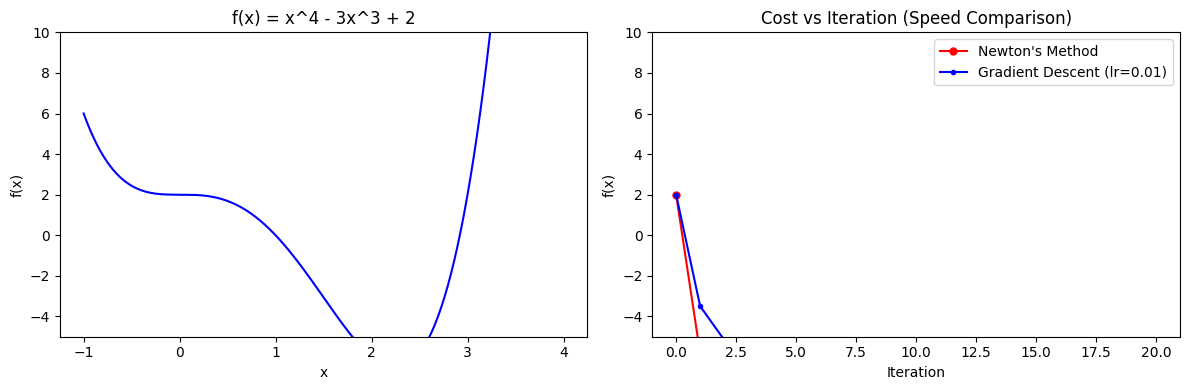


Observation: Newton's method converges in very few iterations.
Gradient descent needs more iterations for the same result.


In [7]:
# Example 2: Newton's Method vs Gradient Descent on f(x) = x^4 - 3x^3 + 2

def f2(x):
    return x**4 - 3*x**3 + 2

def grad_f2(x):
    return 4*x**3 - 9*x**2       # first derivative

def hessian_f2(x):
    return 12*x**2 - 18*x        # second derivative

# --- Newton's Method ---
x_newton = 3.0
lr_newton = 1.0                  # full Newton step
cost_newton = [f2(x_newton)]
iterations = 20

for _ in range(iterations):
    g = grad_f2(x_newton)
    h = hessian_f2(x_newton)
    if abs(h) < 1e-10:           # avoid division by near-zero
        break
    x_newton = x_newton - lr_newton * g / h
    cost_newton.append(f2(x_newton))

# --- Gradient Descent ---
x_gd = 3.0
lr_gd = 0.01
cost_gd = [f2(x_gd)]

for _ in range(iterations):
    x_gd = x_gd - lr_gd * grad_f2(x_gd)
    cost_gd.append(f2(x_gd))

print("Newton's Method  -- Final x: {:.6f},  f(x): {:.6f}".format(x_newton, f2(x_newton)))
print("Gradient Descent -- Final x: {:.6f},  f(x): {:.6f}".format(x_gd, f2(x_gd)))

# Plot comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
x_range = np.linspace(-1, 4, 300)
plt.plot(x_range, f2(x_range), 'b-', label='f(x)')
plt.title("f(x) = x^4 - 3x^3 + 2")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5, 10)

plt.subplot(1, 2, 2)
plt.plot(cost_newton, 'r-o', markersize=5, label="Newton's Method")
plt.plot(cost_gd, 'b-o', markersize=3, label='Gradient Descent (lr=0.01)')
plt.title('Cost vs Iteration (Speed Comparison)')
plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.legend()
plt.ylim(-5, 10)

plt.tight_layout()
plt.show()

print("\nObservation: Newton's method converges in very few iterations.")
print("Gradient descent needs more iterations for the same result.")

---
## Example 3: Role of Learning Rate in Newton's Method

**Function:** f(x) = x^4 - 4x^2

**First Derivative:** f'(x) = 4x^3 - 8x

**Second Derivative:** f''(x) = 12x^2 - 8

The update rule becomes:
```
x_new = x - alpha * f'(x) / f''(x)
```

By adding a learning rate (alpha), we control how much of the Newton step to take.
- alpha = 1.0  Full Newton step (fastest convergence for well-behaved functions)
- alpha < 1.0  Damped Newton step (more cautious, safer near tricky regions)
- alpha > 1.0  Overstep (can cause instability)

alpha=0.2: Final x=1.4490,  f(x)=-3.9901
alpha=0.5: Final x=1.4142,  f(x)=-4.0000
alpha=1.0: Final x=1.4142,  f(x)=-4.0000


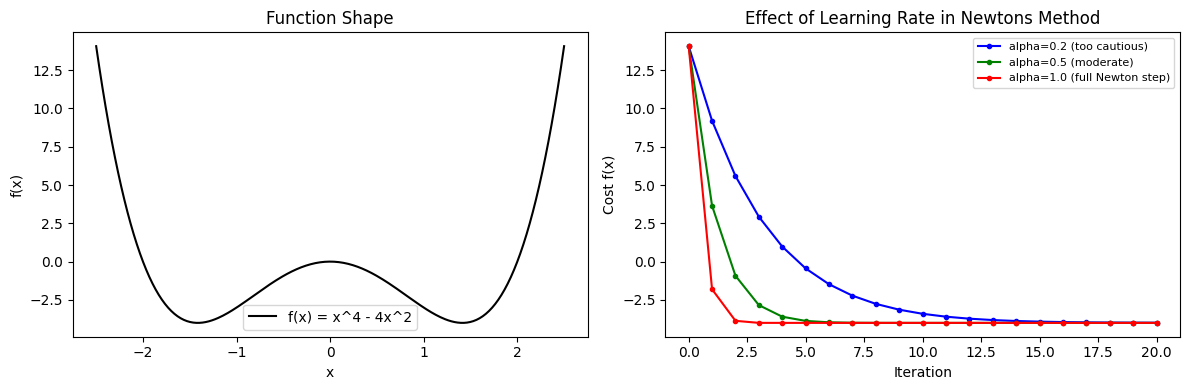


Observation:
- Smaller alpha converges slowly but safely.
- alpha=1.0 (full Newton step) is fastest for well-behaved functions.


In [8]:
# Example 3: Role of Learning Rate in Newton's Method
# Function: f(x) = x^4 - 4x^2

def f3(x):
    return x**4 - 4*x**2

def grad_f3(x):
    return 4*x**3 - 8*x

def hessian_f3(x):
    return 12*x**2 - 8

def newton_with_lr(start, alpha, iterations=20):
    x = start
    cost_history = [f3(x)]
    for _ in range(iterations):
        g = grad_f3(x)
        h = hessian_f3(x)
        if abs(h) < 1e-10:
            break
        x = x - alpha * g / h
        cost_history.append(f3(x))
    return cost_history, x

start_x = 2.5
alphas = [0.2, 0.5, 1.0]
colors = ['blue', 'green', 'red']
labels = ['alpha=0.2 (too cautious)', 'alpha=0.5 (moderate)', 'alpha=1.0 (full Newton step)']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
x_range = np.linspace(-2.5, 2.5, 300)
plt.plot(x_range, f3(x_range), 'k-', label='f(x) = x^4 - 4x^2')
plt.title('Function Shape')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.subplot(1, 2, 2)
for alpha, color, label in zip(alphas, colors, labels):
    history, final_x = newton_with_lr(start_x, alpha)
    plt.plot(history, color=color, marker='o', markersize=3, label=label)
    print(f"alpha={alpha}: Final x={final_x:.4f},  f(x)={f3(final_x):.4f}")

plt.title('Effect of Learning Rate in Newtons Method')
plt.xlabel('Iteration')
plt.ylabel('Cost f(x)')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nObservation:")
print("- Smaller alpha converges slowly but safely.")
print("- alpha=1.0 (full Newton step) is fastest for well-behaved functions.")

---
## Example 4: Newton's Method in 2D (Multivariable)

**Function:** f(x, y) = x^2 + xy + 2y^2

**Gradient (vector of first derivatives):**
- df/dx = 2x + y
- df/dy = x + 4y

**Hessian Matrix (matrix of second derivatives):**
```
H = | d^2f/dx^2   d^2f/dxdy |   =   | 2   1 |
    | d^2f/dydx   d^2f/dy^2 |       | 1   4 |
```

**Newton's 2D Update Rule:**
```
[x, y]_new = [x, y] - H_inverse * gradient
```

We invert the Hessian and multiply by the gradient to get the update direction.

In [ ]:
# Example 4: Newton's Method in 2D
# Function: f(x, y) = x^2 + xy + 2y^2

def f4(x, y):
    return x**2 + x*y + 2*y**2

def gradient_f4(x, y):
    df_dx = 2*x + y
    df_dy = x + 4*y
    return np.array([df_dx, df_dy])

def hessian_f4():
    # This Hessian is constant (function is quadratic)
    return np.array([[2, 1],
                     [1, 4]])

# Starting point
x, y = 5.0, 4.0
alpha = 1.0
iterations = 15

path_x = [x]
path_y = [y]
cost_history = [f4(x, y)]

H = hessian_f4()
H_inv = np.linalg.inv(H)      # invert the Hessian once (constant here)

print("Hessian Matrix:")
print(H)
print("\nHessian Inverse:")
print(np.round(H_inv, 4))

print(f"\n{'Iter':<6} {'x':>10} {'y':>10} {'f(x,y)':>12}")
print("-" * 40)
print(f"{0:<6} {x:>10.4f} {y:>10.4f} {f4(x,y):>12.4f}")

for i in range(iterations):
    g = gradient_f4(x, y)
    params = np.array([x, y])
    params = params - alpha * H_inv @ g   # Newton update in matrix form
    x, y = params
    path_x.append(x)
    path_y.append(y)
    cost_history.append(f4(x, y))
    print(f"{i+1:<6} {x:>10.6f} {y:>10.6f} {f4(x,y):>12.8f}")

print(f"\nMinimum found at x = {x:.8f},  y = {y:.8f}")
print(f"Expected minimum at x = 0.0, y = 0.0")

# Contour Plot
x_range = np.linspace(-6, 6, 200)
y_range = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = f4(X, Y)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=25, cmap='viridis')
plt.colorbar(label='f(x, y)')
plt.plot(path_x, path_y, 'r-o', markersize=5, label="Newton's path")
plt.scatter([0], [0], color='yellow', s=150, zorder=6, label='Minimum (0,0)')
plt.title("Newton's Method on f(x,y) = x^2 + xy + 2y^2")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cost_history, 'g-o', markersize=4)
plt.title('Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('f(x, y)')

plt.tight_layout()
plt.show()

---
## Example 5: Newton's Method with Cost Function and Gradient Check

**Function:** f(x) = x^3 - 6x^2 + 9x + 1

**First Derivative:** f'(x) = 3x^2 - 12x + 9

**Second Derivative:** f''(x) = 6x - 12

This function has:
- A local maximum at x = 1 (f''(1) = -6 < 0)
- A local minimum at x = 3 (f''(3) = 6 > 0)

This example also shows how to compute the gradient numerically (without deriving it by hand) and verify it matches the analytical gradient.

**Numerical Gradient Approximation:**
```
f'(x) approximately = [f(x + h) - f(x - h)] / (2h)
```
where h is a very small number (like 1e-5).

In [ ]:
# Example 5: Newton's Method with Numerical Gradient Check
# Function: f(x) = x^3 - 6x^2 + 9x + 1

def f5(x):
    return x**3 - 6*x**2 + 9*x + 1

def grad_f5_analytical(x):
    return 3*x**2 - 12*x + 9     # exact formula

def hessian_f5(x):
    return 6*x - 12              # exact second derivative

def numerical_gradient(func, x, h=1e-5):
    return (func(x + h) - func(x - h)) / (2 * h)    # central difference

# Gradient check at a few points
print("Gradient Verification (Analytical vs Numerical):")
print(f"{'x':>6} {'Analytical':>14} {'Numerical':>14} {'Match':>10}")
print("-" * 46)
for xval in [0.0, 1.5, 2.0, 3.5, 5.0]:
    a = grad_f5_analytical(xval)
    n = numerical_gradient(f5, xval)
    match = "YES" if abs(a - n) < 1e-6 else "NO"
    print(f"{xval:>6.1f} {a:>14.6f} {n:>14.6f} {match:>10}")

# Newton's Method starting near the minimum
x = 4.0
alpha = 1.0
iterations = 20
tolerance = 1e-8

path_x = [x]
path_f = [f5(x)]

print(f"\nNewton's Method starting at x = {x}")
print(f"{'Iter':<6} {'x':>12} {'f(x)':>12} {'|grad|':>12}")
print("-" * 44)

for i in range(iterations):
    g = grad_f5_analytical(x)
    h = hessian_f5(x)
    if abs(h) < 1e-10:
        print("Hessian near zero, stopping.")
        break
    x_new = x - alpha * g / h
    x = x_new
    path_x.append(x)
    path_f.append(f5(x))
    print(f"{i+1:<6} {x:>12.8f} {f5(x):>12.8f} {abs(g):>12.8f}")
    if abs(g) < tolerance:
        print(f"Converged at iteration {i+1}")
        break

print(f"\nMinimum found at x = {x:.6f},  f(x) = {f5(x):.6f}")
print(f"True local minimum at x = 3,  f(3) = {f5(3):.6f}")

# Plot
x_range = np.linspace(0, 6, 300)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_range, f5(x_range), 'b-', label='f(x)')
plt.scatter(path_x, [f5(v) for v in path_x], color='red', s=50, zorder=5, label="Newton's steps")
plt.scatter([3], [f5(3)], color='gold', s=150, zorder=6, label='True minimum (x=3)')
plt.title("Newton's Method on f(x) = x^3 - 6x^2 + 9x + 1")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(path_f, 'g-o', markersize=5)
plt.title('f(x) vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('f(x)')

plt.tight_layout()
plt.show()

---
# Exercise Questions

Try solving these on your own using what you have learned. Build on the code patterns from the examples above.

---

### Question 1
Apply Newton's method to minimize:

f(x) = (x - 4)^2 + 3

- Derive f'(x) and f''(x) analytically.
- Start at x = 10, use alpha = 1.0, and run for 10 iterations.
- Print a table showing iteration, x, and f(x) at each step.
- How many iterations does it take to reach the minimum? Why?
- Plot the descent path on the curve.

---

### Question 2
Apply Newton's method to the non-quadratic function:

f(x) = x^4 - 8x^2 + 5x

- Derive f'(x) and f''(x).
- Try starting points x = 3.0 and x = -3.0. What different minima does each converge to?
- For each starting point, compare Newton's method (alpha = 1.0) and gradient descent (lr = 0.01) on the same cost vs iteration graph.
- What does this tell you about the effect of starting point?

---

### Question 3
Experiment with different learning rates in Newton's method on:

f(x) = x^3 - 3x

- Derive f'(x) and f''(x).
- Start at x = 2.0 and try alpha values of 0.1, 0.5, 1.0, and 1.5.
- Run each for 25 iterations and plot all cost curves on the same graph.
- Which alpha gives the fastest stable convergence?
- What happens with alpha = 1.5? Explain why.

---

### Question 4
Apply Newton's method in 2D to minimize:

f(x, y) = 3x^2 + 2xy + 4y^2

- Compute the gradient vector: [df/dx, df/dy].
- Compute the Hessian matrix H (2x2 matrix of second derivatives).
- Invert H using numpy.linalg.inv.
- Apply Newton's update: params = params - H_inv @ gradient.
- Start at (x, y) = (6, 5) and run for 10 iterations.
- Plot a contour map with the full descent path.
- What are the expected values of x and y at the minimum?

---

### Question 5
Compare Newton's method and gradient descent on the Rosenbrock function:

f(x, y) = (1 - x)^2 + 100*(y - x^2)^2

This is a famous test function in optimization. The minimum is at (x, y) = (1, 1).

Gradient:
- df/dx = -2*(1 - x) - 400*x*(y - x^2)
- df/dy = 200*(y - x^2)

Hessian:
- d^2f/dx^2 = 2 - 400*(y - 3*x^2)
- d^2f/dxdy = d^2f/dydx = -400*x
- d^2f/dy^2 = 200

- Start at (x, y) = (0, 0) and run both methods for 100 iterations.
- For gradient descent use lr = 0.001.
- Plot the contour map with both descent paths.
- Print the final (x, y) found by each method.
- Which method gets closer to (1, 1)?

---

In [ ]:
# Question 1 Solution Space
# Function: f(x) = (x - 4)^2 + 3

# Your code here


In [ ]:
# Question 2 Solution Space
# Function: f(x) = x^4 - 8x^2 + 5x

# Your code here


In [ ]:
# Question 3 Solution Space
# Function: f(x) = x^3 - 3x, different learning rates

# Your code here


In [ ]:
# Question 4 Solution Space
# Function: f(x, y) = 3x^2 + 2xy + 4y^2 (2D Newton's method)

# Your code here


In [ ]:
# Question 5 Solution Space
# Rosenbrock function: f(x, y) = (1-x)^2 + 100*(y - x^2)^2

# Your code here


---
## Summary

| Example | Function | Key Learning |
|---|---|---|
| 1 | f(x) = x^2 | Newton's method converges in 1 step for a pure quadratic |
| 2 | f(x) = x^4 - 3x^3 + 2 | Newton's method is much faster than gradient descent |
| 3 | f(x) = x^4 - 4x^2 | Role of learning rate (damped Newton step) |
| 4 | f(x,y) = x^2 + xy + 2y^2 | Newton's method extended to 2 variables using the Hessian matrix |
| 5 | f(x) = x^3 - 6x^2 + 9x + 1 | Numerical gradient check and convergence near a local minimum |

**Newton's Method vs Gradient Descent:**

| Property | Gradient Descent | Newton's Method |
|---|---|---|
| Uses gradient | Yes | Yes |
| Uses Hessian | No | Yes |
| Step size choice | Manual (learning rate) | Automatic (from curvature) |
| Speed | Slower | Much faster (fewer iterations) |
| Cost per iteration | Cheap | Expensive (Hessian inversion) |
| Works in high dimensions | Yes | Hard (Hessian too large) |

**Core Takeaway:**
Newton's method uses second-order curvature information to take a smarter step at each iteration, leading to much faster convergence. However, computing and inverting the Hessian is expensive for large-scale problems, so in practice quasi-Newton methods like L-BFGS are used instead.

---